# Import


In [31]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'


In [32]:
# Import
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset
from typing import Union, List, Tuple
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import os
import mlflow
import mlflow.pytorch
from datetime import datetime
from matplotlib.colors import ListedColormap
from skimage import io
import shutil
import time


# MLflow run

In [33]:
from mlflow.exceptions import MlflowException
import datetime

# End MLflow run
mlflow.end_run()

# Function to generate a unique experiment name
def generate_experiment_name():
    return f"experiment-{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"

# Function to create and set a new experiment
def set_experiment(experiment_name):
    try:
        experiment = mlflow.get_experiment_by_name(experiment_name)
        if experiment is None:
            mlflow.create_experiment(experiment_name)
            experiment = mlflow.get_experiment_by_name(experiment_name)
        mlflow.set_experiment(experiment_name)
    except MlflowException as e:
        print(f"Error setting experiment: {e}")
        
        
# Generate a unique experiment name and set the experiment
experiment_name = generate_experiment_name()
set_experiment(experiment_name)

# Verify the experiment is set correctly
print(f"Set experiment '{experiment_name}'")


# Start an MLflow run
mlflow.start_run(run_name=f"inference-{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Set experiment 'experiment-2024-07-26_16-50-02'


<ActiveRun: >

# Setup



In [34]:
dropout_rate = 0.5
mlflow.log_param("dropout_rate", dropout_rate)  # Adjust the value as needed

# Définition du modèle
class UNet_Light_RDN(nn.Module):
    def __init__(self, n_channels, n_classes, dropout_rate, bilinear=True):
        super(UNet_Light_RDN, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 32, dropout_rate)
        self.down1 = Down(32, 64, dropout_rate)
        self.down2 = Down(64, 128, dropout_rate)
        self.down3 = Down(128, 256, dropout_rate)
        self.down4 = Down(256, 256, dropout_rate)
        self.up1 = Up(512, 128, dropout_rate, bilinear)
        self.up2 = Up(256, 64, dropout_rate, bilinear)
        self.up3 = Up(128, 32, dropout_rate, bilinear)
        self.up4 = Up(64, 32, dropout_rate, bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),  # Add dropout here
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)  # Add dropout here
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, dropout_rate)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate, bilinear=True):
        super(Up, self).__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels, dropout_rate)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
        diffX = torch.tensor([x2.size()[3] - x1.size()[3]])

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)




# Load model


In [35]:

# Load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "C:/Users/n.vanderesse/Desktop/STAGE_Nolan/Git/IA-SeReOs/RDN_adapted.pth"
dropout_rate = 0.5  # Define the dropout rate
net = UNet_Light_RDN(n_channels=3, n_classes=3, dropout_rate=dropout_rate)  # Use appropriate n_channels
net.load_state_dict(torch.load(model_path, map_location=device))

# Load the model using MLflow
#model_uri = "runs:/<run_id>/model"  # Replace <run_id> with the actual run ID where the model was saved
#net = mlflow.pytorch.load_model(model_uri)
net.to(device)
net.eval()

# Verify if the model file exists
if not os.path.exists(model_path):
    print(f"Model file not found at {model_path}")
else:
    print("Model loaded successfully.")
    mlflow.pytorch.log_model(net, "model")

# Log parameters
mlflow.log_param("model_path", model_path)

# Log parameters
mlflow.log_param("model_path", model_path)





Model loaded successfully.


'C:/Users/n.vanderesse/Desktop/STAGE_Nolan/Git/IA-SeReOs/RDN_adapted.pth'

In [40]:
def load_image(image_path):
    image = Image.open(image_path).convert('L')
    transform = transforms.ToTensor()
    return transform(image).unsqueeze(0).to(device)

def get_neighbor_paths_dir(image_index, directory, start_index, end_index):
    neighbors = [
        image_index - 1 if image_index > start_index else None,
        image_index,
        image_index + 1 if image_index < end_index else None
    ]
    neighbor_paths = [os.path.join(directory, f"deux_{n:04d}.tif") if n else None for n in neighbors]
    return neighbor_paths

def get_neighbor_paths_seq(image_index, directory, start_index, end_index):
    neighbors = [
        image_index - 1 if image_index > start_index else start_index,
        image_index,
        image_index + 1 if image_index < end_index else end_index
    ]
    neighbor_paths = [os.path.join(directory, f"slice_{n:04d}.tif").replace("\\", "/") for n in neighbors]
    return neighbor_paths




def load_2_5D_image(image_path, neighbor_paths):
    images = [Image.open(p.replace("\\", "/")).convert('L') for p in [image_path] + neighbor_paths if p is not None]
    image_stack = np.stack([np.array(img) for img in images], axis=-1)

    # Ensure only three channels (previous, current, next)
    if image_stack.shape[-1] > 3:
        image_stack = image_stack[..., :3]

    # Transpose to [channels, height, width]
    image_stack = image_stack.transpose(2, 0, 1)

    return image_stack


# Define the new load_2_5D_image_dir function
def load_2_5D_image_dir(image_path, neighbor_paths):
    images = []
    for p in [image_path] + neighbor_paths:
        if p is not None:
            p = p.replace("\\", "/")
            print(f"Loading image from path: {p}")
            images.append(Image.open(p).convert('L'))
    image_stack = np.stack([np.array(img) for img in images], axis=-1)

    # Ensure only three channels (previous, current, next)
    if image_stack.shape[-1] > 3:
        image_stack = image_stack[..., :3]

    # Add batch dimension and reshape to [batch_size, channels, height, width]
    image_stack = np.expand_dims(image_stack, axis=0)  # [1, height, width, channels]
    image_stack = np.transpose(image_stack, (0, 3, 1, 2))  # [1, channels, height, width]

    return image_stack




def create_slices(image_path, base_directory, start_index, end_index):
    img_3d = io.imread(image_path)
    print(f"Loaded 3D image with shape: {img_3d.shape}")

    if not os.path.exists(base_directory):
        os.makedirs(base_directory)

    for i in range(start_index, end_index + 1):
        slice_path = os.path.join(base_directory, f"slice_{i:04d}.tif").replace("\\", "/")
        Image.fromarray(img_3d[i - start_index]).save(slice_path)
        print(f"Saved slice {i} to {slice_path}")

# Inference

Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Unique values in the prediction: [1 2]


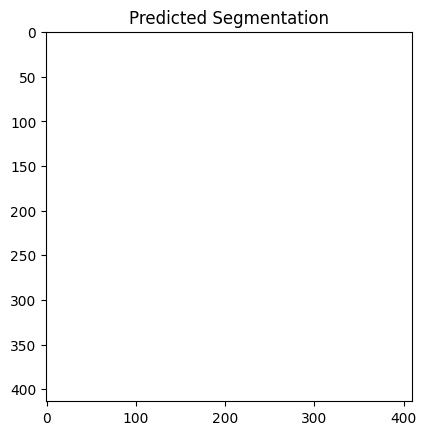

In [39]:
def run_inference(input_tensor):
    input_tensor = input_tensor.unsqueeze(0)  # Add batch dimension if not already present
    print(f"Input tensor shape: {input_tensor.shape}, dtype: {input_tensor.dtype}")
    with torch.no_grad():
        output = net(input_tensor)
        print(f"Model output shape: {output.shape}, dtype: {output.dtype}")
        pred = torch.argmax(output, dim=1).cpu().numpy()
    print(f"Prediction shape: {pred.shape}, unique values: {np.unique(pred)}")
    return pred[0]  # Remove batch dimension


# Example usage for debugging
image_path = "D:/Donnees_pour_segmentation_RDN/data/deux/Unseg/deux_0801.tif"
neighbors = get_neighbor_paths_seq(800,"D:/Donnees_pour_segmentation_RDN/data/deux/Unseg",800,1200)
input_tensor = load_2_5D_image(image_path, neighbors)

# Transform numpy array to tensor
input_tensor = torch.from_numpy(input_tensor).to(device).float()

prediction = run_inference(input_tensor)

# Inspect the prediction
unique_values = np.unique(prediction)
print(f"Unique values in the prediction: {unique_values}")

# Visualize the prediction
segmented_image = visualize_slice(prediction)
plt.imshow(segmented_image, cmap='gray')
plt.title('Predicted Segmentation')
plt.show()

# Visualization

In [41]:
def visualize_slice(prediction):
    grayscale_map = {
        2: 255,  # Bone (white)
        1: 128,  # Dirt (gray)
        0: 0     # Air (black)
    }
    segmented_image = np.zeros_like(prediction, dtype=np.uint8)
    for class_value, grayscale_value in grayscale_map.items():
        segmented_image[prediction == class_value] = grayscale_value
    return segmented_image

def plot_results(img_3d, segmented_3d, slice_indices=None):
    print(f"Shape of img_3d: {img_3d.shape}")  # Debugging line
    print(f"Shape of segmented_3d: {segmented_3d.shape}")  # Debugging line

    middle_slice_index = img_3d.shape[0] // 2 if slice_indices is None else slice_indices[0]
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_3d[middle_slice_index], cmap='gray')
    ax[0].set_title('Input Image (Middle Slice)')
    ax[1].imshow(segmented_3d[middle_slice_index - start_index], cmap='gray')
    ax[1].set_title('Segmented Image (Middle Slice)')
    for a in ax:
        a.axis('off')
    plt.show()

# Directory inference (use for directories)

In [42]:
def empty_directory(directory):
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename).replace("\\", "/")
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                os.rmdir(file_path)
        except Exception as e:
            print(f'Failed to delete {file_path}. Reason: {e}')

def copy_files(file_paths, destination_dir):
    for file_path in file_paths:
        shutil.copy(file_path, destination_dir)

def get_num_digits(directory):
    files = [f for f in os.listdir(directory) if f.endswith('.tif')]
    if not files:
        raise ValueError("No .tif files found in the directory")
    num_digits = len(files[0].split('_')[-1].split('.')[0])
    return num_digits

def get_image_files_by_index(directory, start_index, end_index):
    num_digits = get_num_digits(directory)
    image_files = []
    for idx in range(start_index, end_index + 1):
        file_name = f"{directory}/deux_{idx:0{num_digits}}.tif"
        if os.path.exists(file_name):
            image_files.append(file_name)
        else:
            print(f"File not found: {file_name}")
    return image_files

def get_image_files(directory, extensions=['.tif', '.png', '.jpg', '.jpeg']):
    image_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.lower().endswith(tuple(extensions))]
    return image_files

def process_image_file_dir(image_path, output_dir, start_index, end_index):
    neighbor_paths = get_neighbor_paths_dir(int(os.path.basename(image_path).split('_')[-1].split('.')[0]), os.path.dirname(image_path), start_index, end_index)
    input_tensor = load_2_5D_image(image_path, neighbor_paths)
    input_tensor = torch.from_numpy(input_tensor).to(device).float()  # Ensure float type

    try:
        prediction = run_inference(input_tensor)
        segmented_image = visualize_slice(prediction)
        output_path = os.path.join(output_dir, os.path.basename(image_path))
        Image.fromarray(segmented_image).save(output_path)
        return output_path
    except ValueError as e:
        print(f"Skipping image {image_path} due to error: {e}")
        return None

# Update the process_image_directory function
def process_image_directory(input_dir, output_dir, start_index, end_index):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    image_files = get_image_files(input_dir)
    for image_path in image_files:
        print(f"Processing image: {image_path}")
        output_path = process_image_file_dir(image_path, output_dir, start_index, end_index)
        if output_path:
            mlflow.log_artifact(output_path)
            print(f"Segmented image saved to: {output_path}")





# Application

Loaded 3D image with shape: (1985, 414, 410)
Saved slice 1 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0001.tif
Saved slice 2 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0002.tif
Saved slice 3 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0003.tif
Saved slice 4 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0004.tif
Saved slice 5 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0005.tif
Saved slice 6 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0006.tif
Saved slice 7 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0007.tif
Saved slice 8 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0008.tif
Saved slice 9 to D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0009.tif
Saved slice 10 to D:/Donnees_pour_segmentation

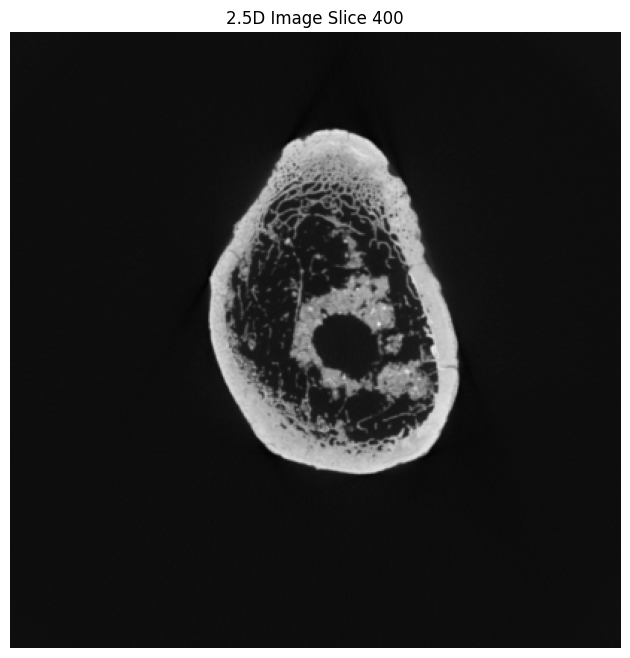

Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 401/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0400.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0401.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0402.tif']
Input tensor shape after unsqueeze: torch.Size([3, 414, 410]), dtype: torch.float32
Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 402/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0401.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0402.tif', 'D:

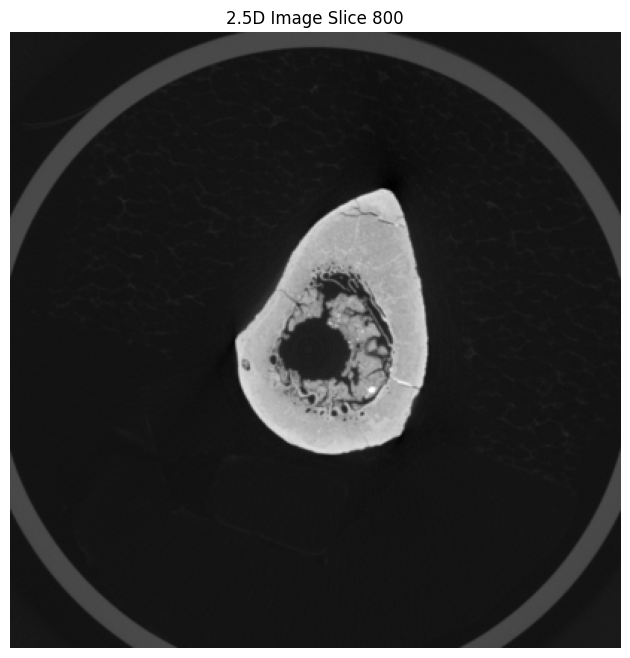

Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 801/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0800.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0801.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0802.tif']
Input tensor shape after unsqueeze: torch.Size([3, 414, 410]), dtype: torch.float32
Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 802/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0801.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_0802.tif', 'D:

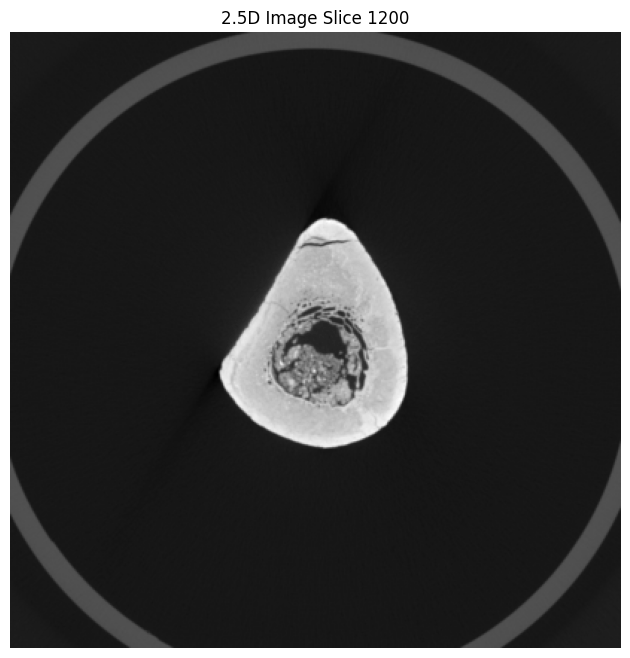

Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 1201/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1200.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1201.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1202.tif']
Input tensor shape after unsqueeze: torch.Size([3, 414, 410]), dtype: torch.float32
Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 1202/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1201.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1202.tif', '

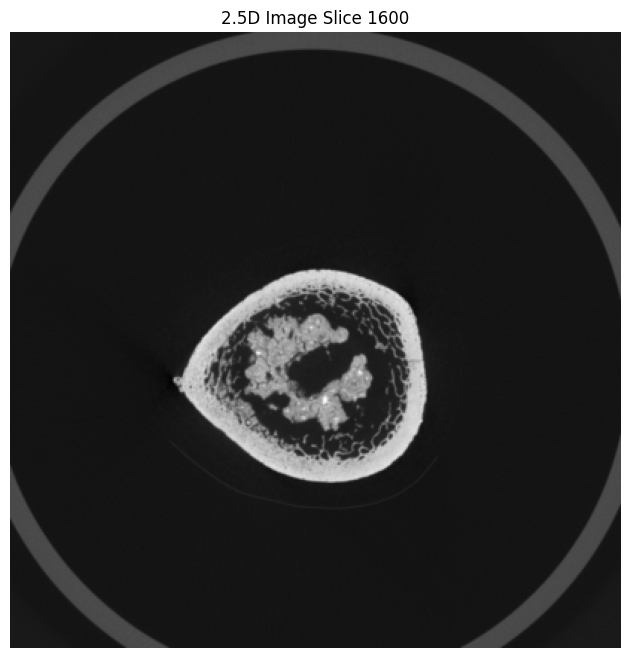

Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 1601/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1600.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1601.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1602.tif']
Input tensor shape after unsqueeze: torch.Size([3, 414, 410]), dtype: torch.float32
Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Processing slice 1602/1872
Neighbor paths: ['D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1601.tif', 'D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt/slice_1602.tif', '

C:\Users\n.vanderesse\AppData\Local\Temp\ipykernel_75688\2038552556.py:48: UserWarning: segmented_image_3d.tif is a low contrast image
  io.imsave('segmented_image_3d.tif', segmented_3d)


Shape of img_3d: (1985, 414, 410)
Shape of segmented_3d: (1872, 414, 410)


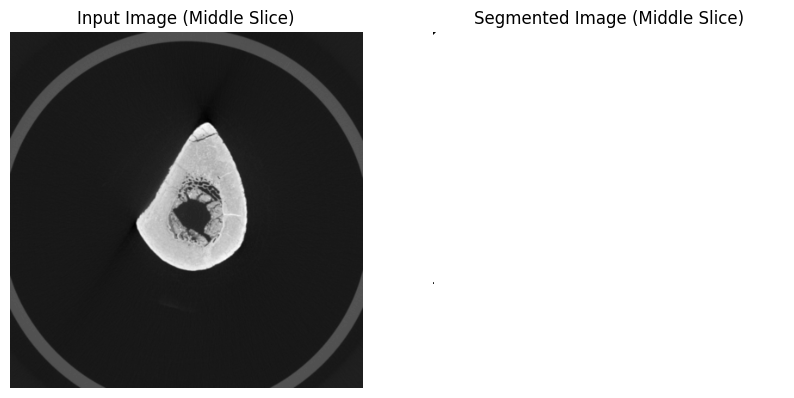

In [43]:
# Application Block



# Visualize a 2.5D image
def visualize_2_5d_image(image_tensor, title):
    image_np = image_tensor.cpu().numpy()
    image_np = np.transpose(image_np, (1, 2, 0))  # Change shape from [channels, height, width] to [height, width, channels]

    plt.figure(figsize=(8, 8))
    plt.imshow(image_np[:, :, 1], cmap='gray')  # Display the middle slice for simplicity
    plt.title(title)
    plt.axis('off')
    plt.show()

# Process 3D Image Function
def process_3d_image(image_path, base_directory, start_index, end_index):
    img_3d = io.imread(image_path)
    print(f"Loaded 3D image with shape: {img_3d.shape}")

    predictions = []
    for i in range(start_index, end_index + 1):
        print(f"Processing slice {i + 1 - start_index}/{end_index - start_index + 1}")
        slice_path = os.path.join(base_directory, f"slice_{i:04d}.tif")
        neighbor_paths = get_neighbor_paths_seq(i, base_directory, start_index, end_index)
        print(f"Neighbor paths: {neighbor_paths}")

        input_tensor = load_2_5D_image(slice_path, neighbor_paths)
        input_tensor = torch.from_numpy(input_tensor).to(device).float()
        input_tensor = input_tensor.squeeze(0)  # remove batch dimension
        print(f"Input tensor shape after unsqueeze: {input_tensor.shape}, dtype: {input_tensor.dtype}")

        # Visualize the 2.5D image before inference
        if i % 400 == 0:  # Visualize every 100 slices (adjust as needed)
            visualize_2_5d_image(input_tensor, f"2.5D Image Slice {i}")

        try:
            prediction = run_inference(input_tensor)
            segmented_slice = visualize_slice(prediction)
            predictions.append(segmented_slice)
        except ValueError as e:
            print(f"Skipping slice {i} due to error: {e}")

    if not predictions:
        raise ValueError("No valid predictions were generated")

    segmented_3d = np.stack(predictions, axis=0)
    io.imsave('segmented_image_3d.tif', segmented_3d)
    mlflow.log_artifact('segmented_image_3d.tif')

    plot_results(img_3d, segmented_3d)





    
# Application for 3D image
start_index = 1 
end_index = 1872
image_path = "D:/Donnees_pour_segmentation_RDN/data/deux.tif"
base_directory = "D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_adapt"
os.makedirs(base_directory, exist_ok=True)
empty_directory(base_directory)
mlflow.log_param("image_path", image_path)

# Create slices
create_slices(image_path, base_directory, start_index, end_index)

process_3d_image(image_path, base_directory, start_index, end_index)

# End the MLflow run
mlflow.end_run()

# Application for directory

In [44]:
start_index = 851
end_index = 1851

input_dir = "D:/Donnees_pour_segmentation_RDN/data/deux/Unseg"
inference_files = get_image_files_by_index(input_dir, start_index=start_index, end_index=end_index)

input_directory = "D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_input"
output_directory = "D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_output"

os.makedirs(input_directory, exist_ok=True)
os.makedirs(output_directory, exist_ok=True)

empty_directory(input_directory)
empty_directory(output_directory)

copy_files(inference_files, input_directory)

mlflow.log_param("input_directory", input_directory)
mlflow.log_param("output_directory", output_directory)

process_image_directory(input_directory, output_directory, start_index, end_index)

# End the MLflow run
mlflow.end_run()

print("Inference completed successfully.")

Processing image: D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_input\deux_0851.tif
Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Segmented image saved to: D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_output\deux_0851.tif
Processing image: D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_input\deux_0852.tif
Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Prediction shape: (1, 414, 410), unique values: [1 2]
Segmented image saved to: D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_output\deux_0852.tif
Processing image: D:/Donnees_pour_segmentation_RDN/data/inference_test/inference_input\deux_0853.tif
Input tensor shape: torch.Size([1, 3, 414, 410]), dtype: torch.float32
Model output s